<a href="https://colab.research.google.com/github/CarlosJB95/PathIA-MSI-colon/blob/main/Notebook_Semana_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semana 3 · Día 11 — **matplotlib**: líneas, barras, dispersión

---



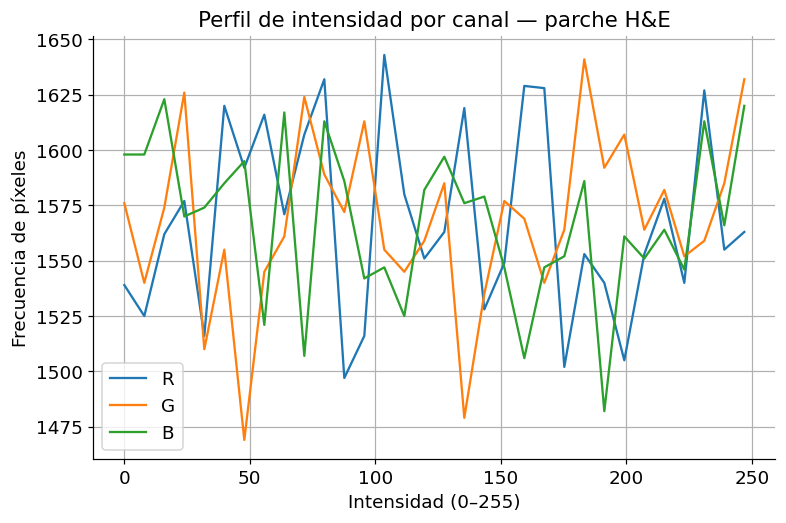

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# parche H&E simulado (o usa un array real del Día 7): (alto, ancho, 3)
parche = np.random.randint(0, 256, size=(224, 224, 3), dtype=np.uint8)

fig, ax = plt.subplots()
for i, canal in enumerate(['R', 'G', 'B']):
    hist, bordes = np.histogram(parche[:, :, i], bins=32, range=(0, 255))
    ax.plot(bordes[:-1], hist, label=canal)

ax.set_title('Perfil de intensidad por canal — parche H&E')
ax.set_xlabel('Intensidad (0–255)')
ax.set_ylabel('Frecuencia de píxeles')
ax.legend()
plt.show()

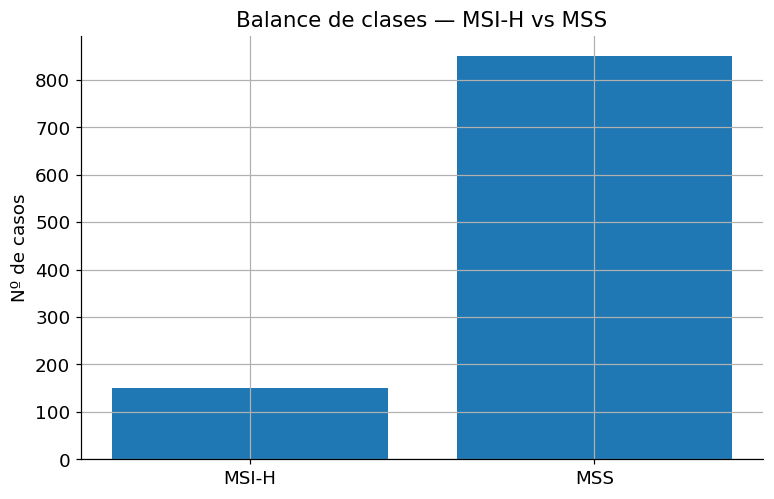

In [56]:
clases = ['MSI-H', 'MSS']
conteos = [150, 850]   # ilustra el desbalance ~15% del CRC

fig, ax = plt.subplots()
ax.bar(clases, conteos)
ax.set_title('Balance de clases — MSI-H vs MSS')
ax.set_ylabel('Nº de casos')
plt.show()

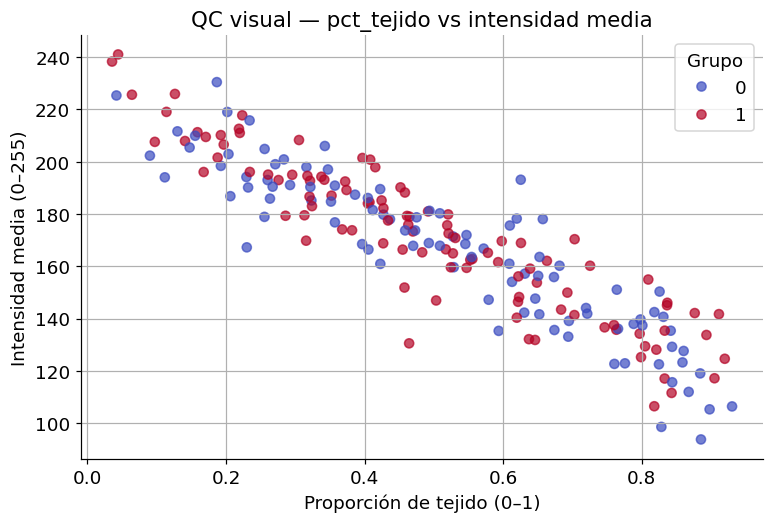

In [57]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

# simula 200 parches: pct_tejido (0–1) e intensidad media (0–255)
pct_tejido = rng.beta(2, 2, 200)
intensidad = 230 - 120 * pct_tejido + rng.normal(0, 12, 200)  # más tejido → más oscuro
grupo = rng.integers(0, 2, 200)   # 0 = MSS, 1 = MSI-H (ilustrativo)

fig, ax = plt.subplots()
sc = ax.scatter(pct_tejido, intensidad, c=grupo, cmap='coolwarm', alpha=0.7)
ax.set_title('QC visual — pct_tejido vs intensidad media')
ax.set_xlabel('Proporción de tejido (0–1)')
ax.set_ylabel('Intensidad media (0–255)')
ax.legend(*sc.legend_elements(), title='Grupo')
plt.show()

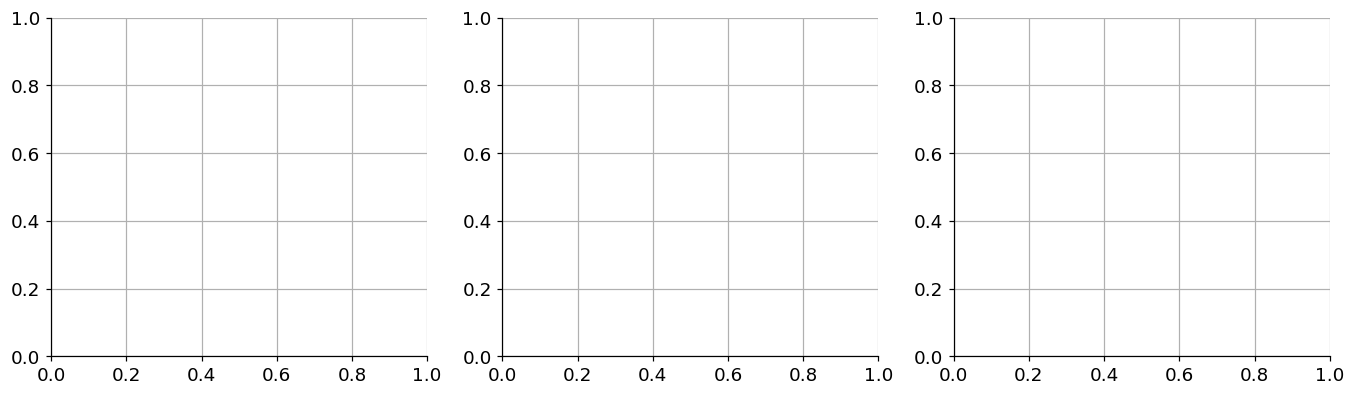

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

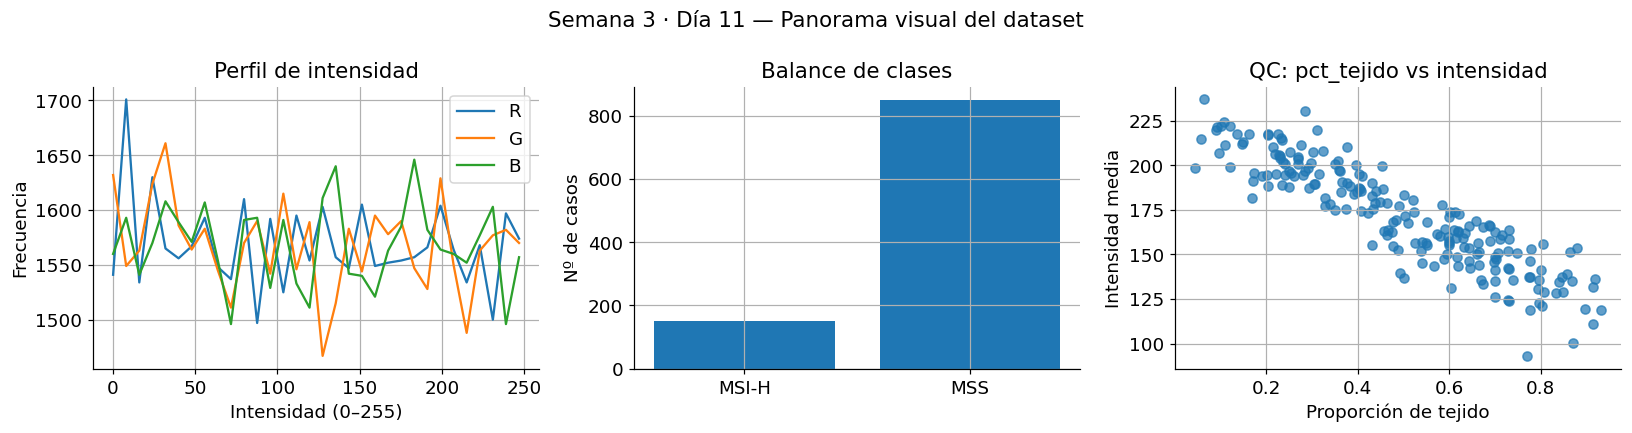

In [59]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Panel 0: líneas (perfil de intensidad) ---
parche = rng.integers(0, 256, size=(224, 224, 3), dtype=np.uint8)
for i, canal in enumerate(['R', 'G', 'B']):
    hist, bordes = np.histogram(parche[:, :, i], bins=32, range=(0, 255))
    axes[0].plot(bordes[:-1], hist, label=canal)
axes[0].set_title('Perfil de intensidad')
axes[0].set_xlabel('Intensidad (0–255)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# --- Panel 1: barras (balance de clases) ---
axes[1].bar(['MSI-H', 'MSS'], [150, 850])
axes[1].set_title('Balance de clases')
axes[1].set_ylabel('Nº de casos')

# --- Panel 2: dispersión (QC visual) ---
pct_tejido = rng.beta(2, 2, 200)
intensidad = 230 - 120 * pct_tejido + rng.normal(0, 12, 200)
axes[2].scatter(pct_tejido, intensidad, alpha=0.7)
axes[2].set_title('QC: pct_tejido vs intensidad')
axes[2].set_xlabel('Proporción de tejido')
axes[2].set_ylabel('Intensidad media')

fig.suptitle('Semana 3 · Día 11 — Panorama visual del dataset', fontsize=14)
fig.tight_layout()
plt.show()

In [60]:
from pathlib import Path

Path('results').mkdir(exist_ok=True)   # crea la carpeta si no existe

fig.savefig(
    'results/dia11_panorama_dataset.png',
    dpi=150,             # resolución: nítido sin ser gigante
    bbox_inches='tight'  # recorta el margen blanco sobrante
)

## **Semana 3 · Día 12 — Histogramas, boxplots y subplots**

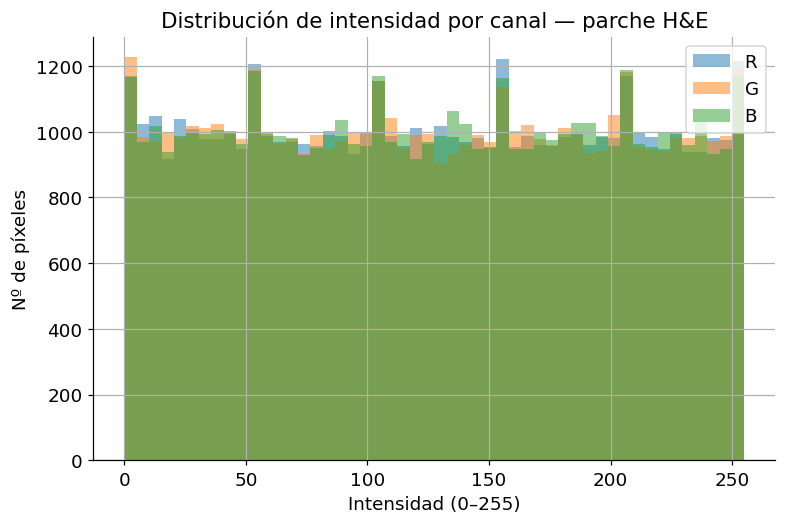

In [61]:
fig, ax = plt.subplots()
for i, canal in enumerate(['R', 'G', 'B']):
    ax.hist(parche[:, :, i].ravel(), bins=50, alpha=0.5, label=canal)
ax.set_title('Distribución de intensidad por canal — parche H&E')
ax.set_xlabel('Intensidad (0–255)')
ax.set_ylabel('Nº de píxeles')
ax.legend()
plt.show()

/tmp/ipykernel_4773/3449890458.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([mss, msih], labels=['MSS', 'MSI-H'])


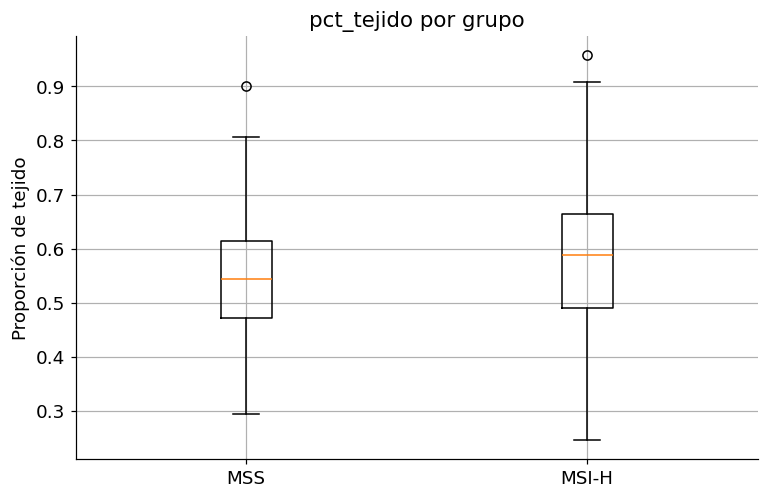

In [62]:
# ilustrativo: pct_tejido simulado para dos grupos
import numpy as np
rng = np.random.default_rng(42)
mss   = rng.normal(0.55, 0.12, 200).clip(0, 1)
msih  = rng.normal(0.58, 0.13, 200).clip(0, 1)

fig, ax = plt.subplots()
ax.boxplot([mss, msih], labels=['MSS', 'MSI-H'])
ax.set_title('pct_tejido por grupo')
ax.set_ylabel('Proporción de tejido')
plt.show()

<Axes: title={'center': 'pct_tejido'}, xlabel='grupo'>

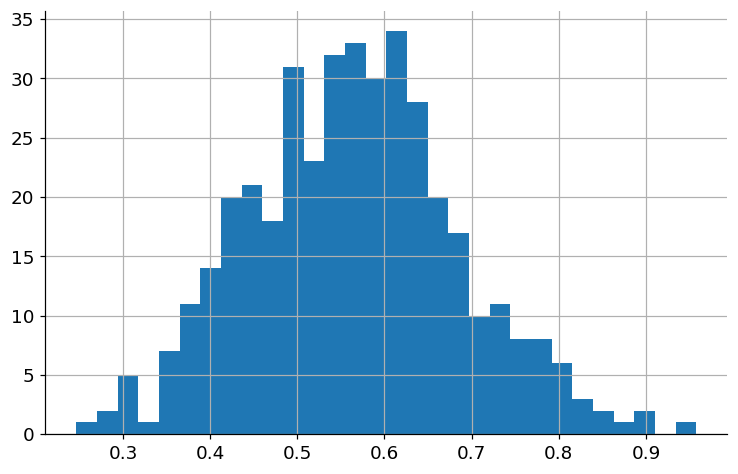

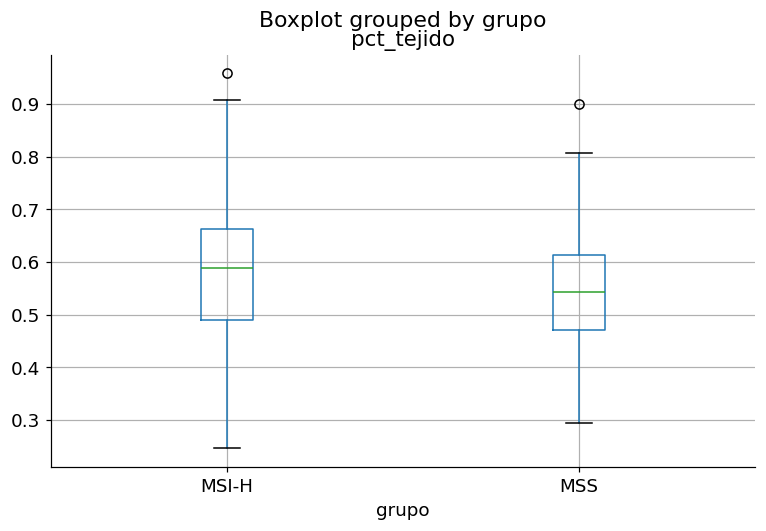

In [63]:
import pandas as pd

# arma un DataFrame con los datos del boxplot
df = pd.DataFrame({
    'pct_tejido': np.concatenate([mss, msih]),
    'grupo': ['MSS']*200 + ['MSI-H']*200
})

df['pct_tejido'].hist(bins=30)          # histograma en 1 línea
df.boxplot(column='pct_tejido', by='grupo')   # boxplot por grupo en 1 línea

/tmp/ipykernel_4773/3654759643.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([mss, msih], labels=['MSS', 'MSI-H'])


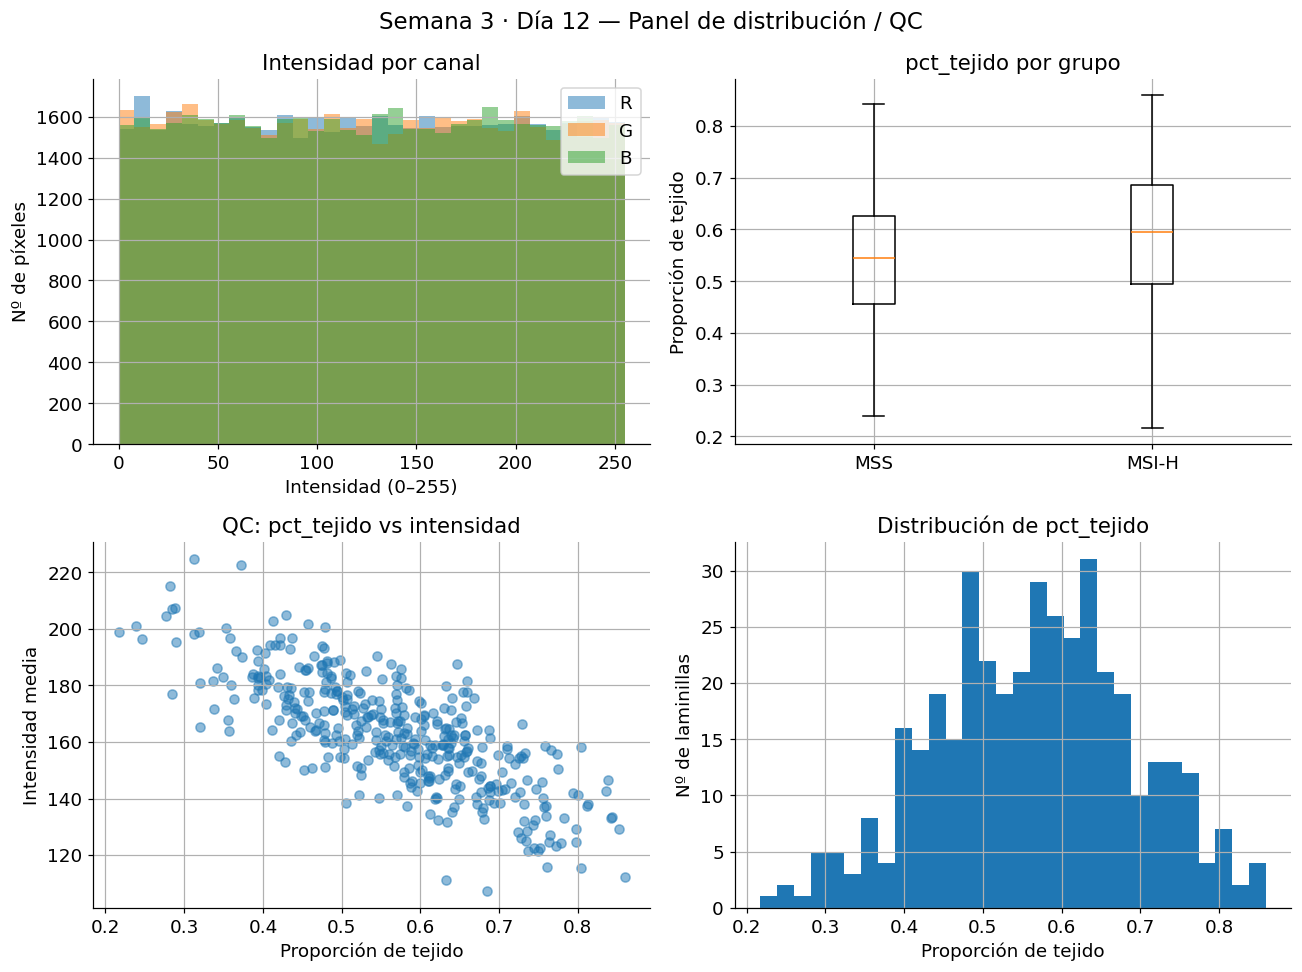

In [64]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

# datos que ya tienes de hoy
parche = rng.integers(0, 256, size=(224, 224, 3), dtype=np.uint8)
mss  = rng.normal(0.55, 0.12, 200).clip(0, 1)
msih = rng.normal(0.58, 0.13, 200).clip(0, 1)
pct_tejido = np.concatenate([mss, msih])
intensidad = 230 - 120 * pct_tejido + rng.normal(0, 12, 400)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (0,0) histograma de intensidad por canal
for i, c in enumerate(['R', 'G', 'B']):
    axes[0, 0].hist(parche[:, :, i].ravel(), bins=32, alpha=0.5, label=c)
axes[0, 0].set_title('Intensidad por canal'); axes[0, 0].legend()
axes[0, 0].set_xlabel('Intensidad (0–255)'); axes[0, 0].set_ylabel('Nº de píxeles')
# (0,1) boxplot pct_tejido por grupo
axes[0, 1].boxplot([mss, msih], labels=['MSS', 'MSI-H'])
axes[0, 1].set_title('pct_tejido por grupo')
axes[0, 1].set_ylabel('Proporción de tejido')
# (1,0) dispersión pct_tejido vs intensidad
axes[1, 0].scatter(pct_tejido, intensidad, alpha=0.5)
axes[1, 0].set_title('QC: pct_tejido vs intensidad')
axes[1, 0].set_xlabel('Proporción de tejido'); axes[1, 0].set_ylabel('Intensidad media')
# (1,1) histograma de pct_tejido
axes[1, 1].hist(pct_tejido, bins=30)
axes[1, 1].set_title('Distribución de pct_tejido')
axes[1, 1].set_xlabel('Proporción de tejido'); axes[1, 1].set_ylabel('Nº de laminillas')
fig.suptitle('Semana 3 · Día 12 — Panel de distribución / QC', fontsize=15)
fig.tight_layout()

fig.savefig('results/fig_distribuciones_qc.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
axes[0, 0].set_xlabel('Intensidad (0–255)'); axes[0, 0].set_ylabel('Nº de píxeles')
axes[0, 1].set_ylabel('Proporción de tejido')
axes[1, 0].set_xlabel('Proporción de tejido'); axes[1, 0].set_ylabel('Intensidad media')
axes[1, 1].set_xlabel('Proporción de tejido'); axes[1, 1].set_ylabel('Nº de laminillas')

Text(694.2875, 0.5, 'Nº de laminillas')

# **Día 13 — Buenas prácticas de visualización**

In [66]:
def aplicar_estilo():
    """Fija el estilo visual estándar del proyecto pathia-msi-colon.
    Llamar una vez al inicio de cada notebook, tras los imports."""
    plt.rcParams.update({
        'figure.dpi': 110,
        'savefig.dpi': 300,
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'axes.grid': True,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.figsize': (8, 5),
    })

aplicar_estilo()

In [67]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'clase_tejido': np.random.choice(
        ['TUM','STR','LYM','MUC','MUS','NORM','ADI','DEB','BACK'], 1000)
})

print(df.columns)   # confirma que aparece 'clase_tejido'
print(df.head())    # ojea las primeras filas

Index(['clase_tejido'], dtype='object')
  clase_tejido
0          STR
1          TUM
2          MUC
3          DEB
4         NORM


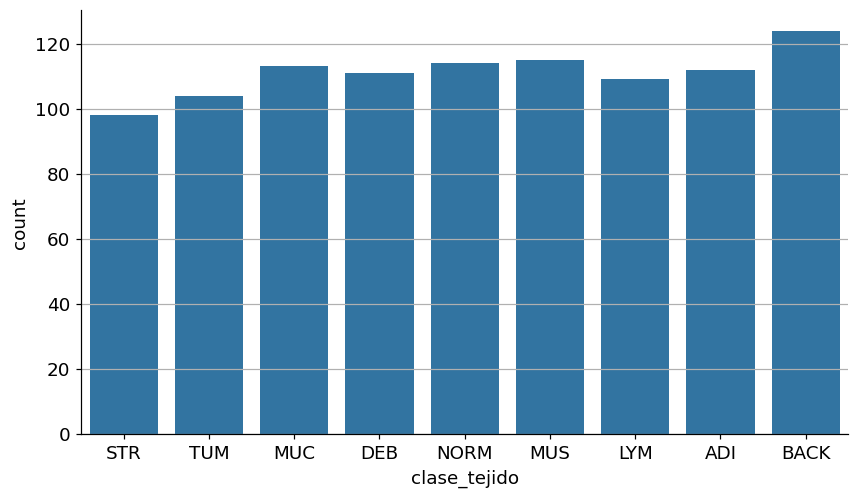

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# df tiene una columna 'clase_tejido' con etiquetas: TUM, STR, LYM, ...
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x='clase_tejido', ax=ax)
plt.show()

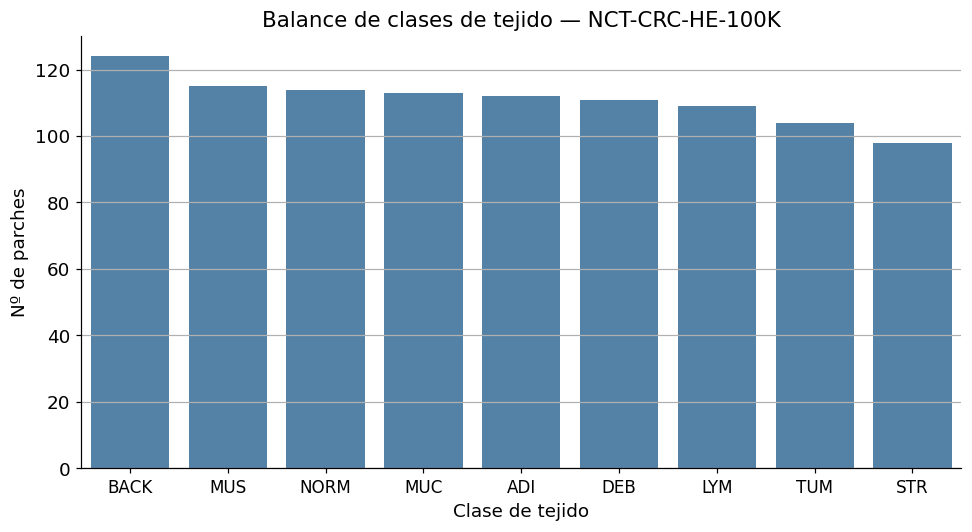

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

orden = df['clase_tejido'].value_counts().index

fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x='clase_tejido', order=orden, ax=ax, color='steelblue')

ax.set_title('Balance de clases de tejido — NCT-CRC-HE-100K', fontsize=14)
ax.set_xlabel('Clase de tejido', fontsize=12)
ax.set_ylabel('Nº de parches', fontsize=12)
ax.tick_params(axis='x', labelsize=11)

fig.tight_layout()
plt.show()

/tmp/ipykernel_4773/2820959657.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([mss, msih], labels=['MSS', 'MSI-H'])


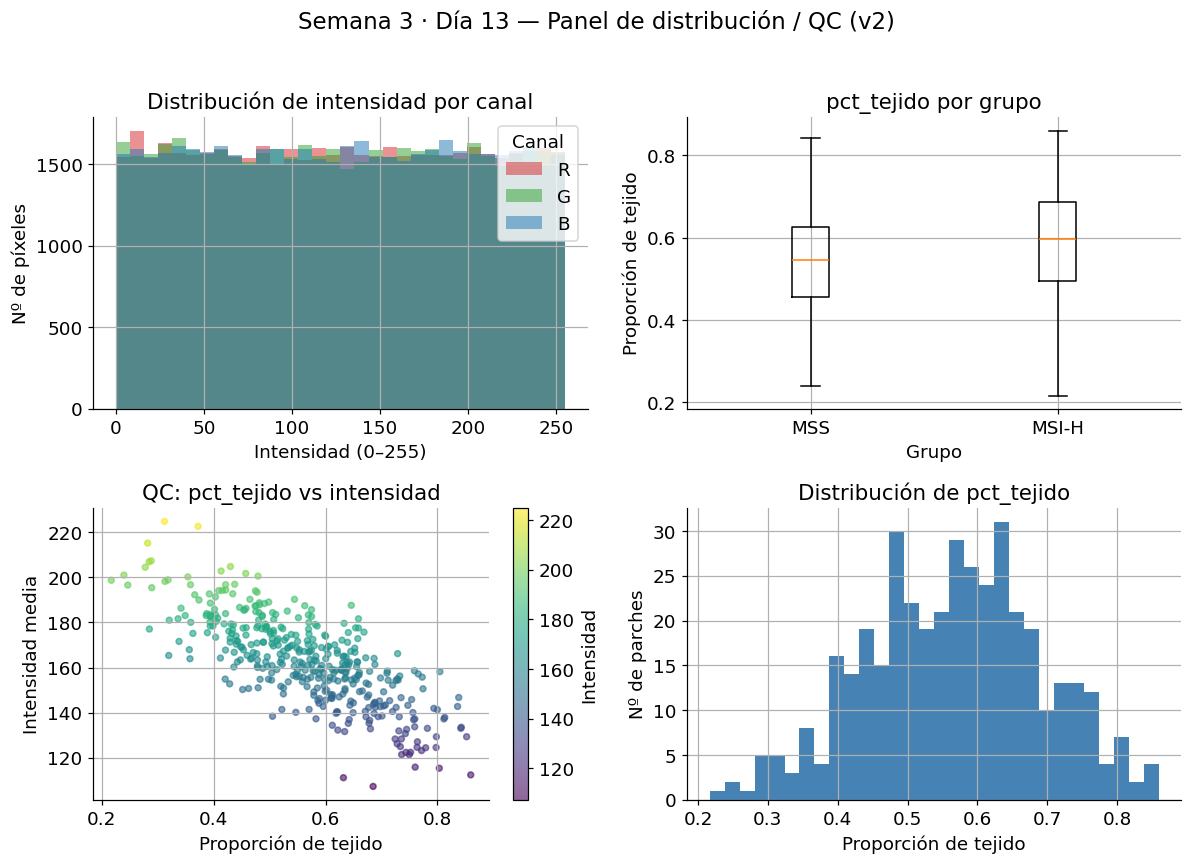

In [70]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

aplicar_estilo()   # estilo global del proyecto

# datos del Día 12
parche = rng.integers(0, 256, size=(224, 224, 3), dtype=np.uint8)
mss  = rng.normal(0.55, 0.12, 200).clip(0, 1)
msih = rng.normal(0.58, 0.13, 200).clip(0, 1)
pct_tejido = np.concatenate([mss, msih])
intensidad = 230 - 120 * pct_tejido + rng.normal(0, 12, 400)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# (0,0) intensidad por canal — colores con SIGNIFICADO (R/G/B reales)
for canal, color in zip('RGB', ['tab:red', 'tab:green', 'tab:blue']):
    idx = 'RGB'.index(canal)
    axes[0, 0].hist(parche[:, :, idx].ravel(), bins=32, alpha=0.5,
                    label=canal, color=color)
axes[0, 0].set_title('Distribución de intensidad por canal')
axes[0, 0].set_xlabel('Intensidad (0–255)')
axes[0, 0].set_ylabel('Nº de píxeles')
axes[0, 0].legend(title='Canal')

# (0,1) boxplot pct_tejido por grupo
axes[0, 1].boxplot([mss, msih], labels=['MSS', 'MSI-H'])
axes[0, 1].set_title('pct_tejido por grupo')
axes[0, 1].set_xlabel('Grupo')
axes[0, 1].set_ylabel('Proporción de tejido')

# (1,0) dispersión pct_tejido vs intensidad — viridis (secuencial)
sc = axes[1, 0].scatter(pct_tejido, intensidad, c=intensidad,
                        cmap='viridis', alpha=0.6, s=15)
axes[1, 0].set_title('QC: pct_tejido vs intensidad')
axes[1, 0].set_xlabel('Proporción de tejido')
axes[1, 0].set_ylabel('Intensidad media')
fig.colorbar(sc, ax=axes[1, 0], label='Intensidad')

# (1,1) histograma de pct_tejido
axes[1, 1].hist(pct_tejido, bins=30, color='steelblue')
axes[1, 1].set_title('Distribución de pct_tejido')
axes[1, 1].set_xlabel('Proporción de tejido')
axes[1, 1].set_ylabel('Nº de parches')

fig.suptitle('Semana 3 · Día 13 — Panel de distribución / QC (v2)', fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig('results/fig_distribuciones_qc_v2.png', dpi=300, bbox_inches='tight')
plt.show()

## ✅ **Checklist de figura publicable — pathIA-MSI-colon**

**Legibilidad**
- [ ] Ejes rotulados CON unidades
- [ ] Título por subplot (+ supertítulo si es panel)
- [ ] Tipografía legible; paneles sin encimarse (tight_layout)
- [ ] Leyenda solo si aporta

**Elección correcta**
- [ ] Tipo de gráfico ↔ pregunta (categórica→barras; distribución→hist/box; relación→dispersión)
- [ ] Bins sensatos (divisor del rango; no fabrican picos)
- [ ] Color con intención (secuencial/categórica/divergente; colorblind-safe; nunca jet)

**Honestidad** ⭐
- [ ] Barras desde 0; ejes truncados SIEMPRE rotulados
- [ ] Sin chartjunk (3D, sombras, color decorativo)
- [ ] La figura no exagera una señal que no está

**Consistencia y reproducibilidad**
- [ ] Estilo uniforme (aplicar_estilo / rcParams)
- [ ] Formato según destino (300 dpi impreso · 150 pantalla)
- [ ] Semilla fija + guardada con nombre versionado + regenerable con Run all